# Skript fürs Training eines RL-Agenten zur Auftragssteuerung
## Hier: Schritt 1, Lager: Trainiere Lager unabhängig vom AGV (der Feinschliff kann ein Training abgestimmt aufs AGV sein)

Der state wird für das Lager anders definiert als für das AGV, möglichst viel soll OHE sein:
10:  Erste 10 Einträge: Anzahl an zu liefernden Waren an die Stationen
10: Nächste 10 Einträge Ampelsystem für Dringlichkeit, Stufe 0: noch nicht dringend, Stufe 1: wird bald dringend, Stufe 2: dringend, Stufe 3: schon zu spät, jetzt aber hallo ;-)
10: Dann 10 Einträge, welche Waren schon auf dem AGV sind
10: Dann 10 Einträge als OHE-Maske, welche Stationen sinnvoll sind anzufahren (nach heuristischer Methodik: Nur die Stationen, die offene Aufträge haben).

Aktion:
1: Fertig, schicke weg von Lager
10: Lade Waren für Station "action" aufs AGV

In [ ]:
import csv
import random
import numpy as np
##### Settting parameters ####

#### AGV
V_MAX = 20
AGV_MAX_CAP = 4

#### ENV
ORDER_TIME_BONUS = 300
STATION_PROCESSING_TIME = 20
STATION_COUNT = 13
TIME_FACTOR = 400


### Points
ORDER_OVERDUE_MINUS = - 0.2 
ORDER_OVERDUE_MINUS_EVERY_SECONDS = 20
POINTS_ORDER_FULFILLED = 1


### Rewards
#REWARD_ORDER_OVERDUE = -0.01


#### Schritt 1: Verteile großen Malus für unsinnige Aufträge, alle anderen 0
#### Schritt 2: Verteile für die anderen auch sinnige Belohnungen
TIME_URGENT_RED = 320
TIME_URGENT_ORANGE = 640
TIME_URGENT_YELLOW = 960


In [ ]:
import factory_environment as env
import agv
import logic
import game_mechanics_4_storage_training as gm_4_st
import RL_Agent

In [ ]:
my_env = env.env('ttable.csv', 'station_number.csv', 'env_control_order.csv')

In [ ]:
my_agv = agv.agv()

In [ ]:
my_logic = logic.logic()

In [ ]:
### State size
# agv: Ladezustand +  ENV: order_list 
STATION_COUNT = 13
# Ladezustand + act_stat + ENV: order list
state_size_agv = 4+13+4+13
state_size_storage = 4*10 + 1
#state_size = state_size_storage

#### Action size
# Fahre zu einer der 13 Stationen
action_size_agv = 13
### Lade auf für eine der 11 Stationen
action_size_storage = 11

In [ ]:
gm = gm_4_st.game_mechanics(my_logic, my_env, my_agv)


## ⚙️ Reinforcement Learning Agent Parameters Explained

### 1. **gamma (γ) – Discount Factor**
- **Purpose**: Controls how much the agent values future rewards versus immediate ones.
- **Range**: Between 0 and 1.
- **Example**:
  - `γ = 0.99` → agent cares a lot about long-term rewards.
  - `γ = 0.1` → agent focuses mostly on immediate results.
- **Effect**: Higher values encourage farsightedness; lower values make the agent more short-term reactive.

---

### 2. **epsilon (ε) – Exploration Rate**
- **Purpose**: Determines the probability of the agent choosing a **random action** (exploration) versus the **best-known action** (exploitation).
- **Range**: Between 0 and 1.
- **Behavior**:
  - `ε = 1.0` → pure exploration (tries everything).
  - `ε = 0.01` → mostly exploits learned policy.
- **Why It Matters**: Without exploration, the agent might miss better strategies.

---

### 3. **epsilon_min**
- **Purpose**: Minimum bound for `epsilon` during training.
- **Prevents**: The agent from becoming completely deterministic too early.
- **Example**: `epsilon_min = 0.01` → agent will always have a 1% chance of trying something new.

---

### 4. **epsilon_decay**
- **Purpose**: Determines how quickly the `epsilon` value decays over time.
- **Example**:
  - `epsilon *= 0.995` per episode → slow decay.
  - `epsilon *= 0.9` → faster decay.
- **Goal**: Start explorative and gradually become confident in its knowledge.

---

### 5. **learning_rate (α)**
- **Purpose**: Determines how much new knowledge overrides old Q-values during updates.
- **Range**: Small positive float, like `0.001`.
- **Trade-off**:
  - High value: Learns fast, might oscillate or forget.
  - Low value: Stable but slow learning.

---

### 6. **memory (Replay Buffer)**
- **Type**: `deque` (double-ended queue) storing past experiences.
- **Why**: Helps decorrelate experiences for better training stability.
- **Stored Values**: Each memory is a tuple of `(state, action, reward, next_state, done)`.

---

### 7. **batch_size**
- **Purpose**: Number of experiences randomly sampled from memory to train on each time.
- **Effect**:
  - Small batch → more frequent updates, less stable.
  - Large batch → more stable updates, slower cycles.

---

### 8. **state_size**
- **What**: Number of features that describe the current environment state.
- **Use**: Defines the input shape of your neural network.

### 9. **action_size**
- **What**: Number of possible actions the agent can take.
- **Use**: Defines the output shape of your neural network.

---

Let me know if you'd like a cheat sheet summarizing this, or if you’re curious about how these interact during training. We can also dive deeper into things like target networks or dueling architectures when you're ready to advance! 🧠✨

In [ ]:
START_POS = 1   # Startet an Lager B

### Sonstige Training-Variablen
GAMES_PER_EPISODE = 8 
EPISODE_COUNT = 20 



#### Variablen für RL-Agent
GAMMA = 0.5  #0.99
EPSILON = 1
EPSILON_MIN = 0.2
EPSILON_DECAY = 0.99
LEARNING_RATE = 0.001#*10
BATCH_SIZE = 512


In [ ]:
loading_storage = ''

my_RL_agent_storage = RL_Agent.DQNAgent(len(gm.act_state_storage), action_size_storage, GAMMA, EPSILON, EPSILON_MIN, EPSILON_DECAY, LEARNING_RATE, loading_storage)
my_RL_agent_storage.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,075 (62.79 KB)

 Trainable params: 16,075 (62.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
######
reward_vec = []
total_time_vec = []
tracker_vec = []
points_vec = []  # ← NEU
gm.reset()
for episode in range(EPISODE_COUNT):
    for game in range(GAMES_PER_EPISODE):
        total_reward, total_time, tracker, stuck = gm.run_game(my_RL_agent_storage)
        if not stuck:
            reward_vec.append(total_reward)
            total_time_vec.append(total_time)
            tracker_vec.append(tracker)
            points_vec.append(gm.env.points)  # ← NEU
        gm.reset()
        my_env.reset()
        my_agv.reset()
    my_RL_agent_storage.replay(BATCH_SIZE)
    print(f'epsilon was: {my_RL_agent_storage.epsilon}')
    my_RL_agent_storage.epsilon *=EPSILON_DECAY
    print(f'mean reward episode {episode}: {np.mean(reward_vec[:-GAMES_PER_EPISODE+1])}')
    print(f'mean total time: {np.mean(total_time_vec[:-GAMES_PER_EPISODE+1])}')
    
        

epsilon was: 1
mean reward episode 0: 0.6000000000000001
mean total time: 397.05882352941177
Maximale Anzahl an Aktionen im Lager überschritten, breche Spiel ab.
epsilon was: 0.98
mean reward episode 1: 2.4275
mean total time: 692.5055899552804
epsilon was: 0.9603999999999999
mean reward episode 2: 2.4612499999999997
mean total time: 679.5242088063295
Maximale Anzahl an Aktionen im Lager überschritten, breche Spiel ab.
epsilon was: 0.9411919999999999
mean reward episode 3: 2.25304347826087
mean total time: 691.9117273148771
epsilon was: 0.9223681599999999
mean reward episode 4: 2.1438709677419356
mean total time: 710.7210626185957
Maximale Anzahl an Aktionen im Lager überschritten, breche Spiel ab.
epsilon was: 0.8858423808639998
mean reward episode 5: 2.1999999999999997
mean total time: 734.8546158999148
Maximale Anzahl an Aktionen im Lager überschritten, breche Spiel ab.
Maximale Anzahl an Aktionen im Lager überschritten, breche Spiel ab.
epsilon was: 0.8507630225817854
mean reward e

In [ ]:
print(f'mittlere Belohnung für die ersten 100 Spiele: {np.mean(reward_vec[0:100])}')
print(f'mittlere Belohnung für die letzten 100 Spiele: {np.mean(reward_vec[:-100])}')
print(f'Abschließendes epsilon: {my_RL_agent_storage.epsilon}')

mittlere Belohnung für die ersten 100 Spiele: 2.2356
mittlere Belohnung für die letzten 100 Spiele: 2.151553544494721
Abschließendes epsilon: 0.061545803450736285


In [ ]:
mean_reward_per_episode = []
for i in range(0,len(reward_vec),GAMES_PER_EPISODE):
    if i % GAMES_PER_EPISODE == 0:
        mean_reward_per_episode.append(np.mean(reward_vec[i:i+GAMES_PER_EPISODE]))
#mean_reward_per_episode        

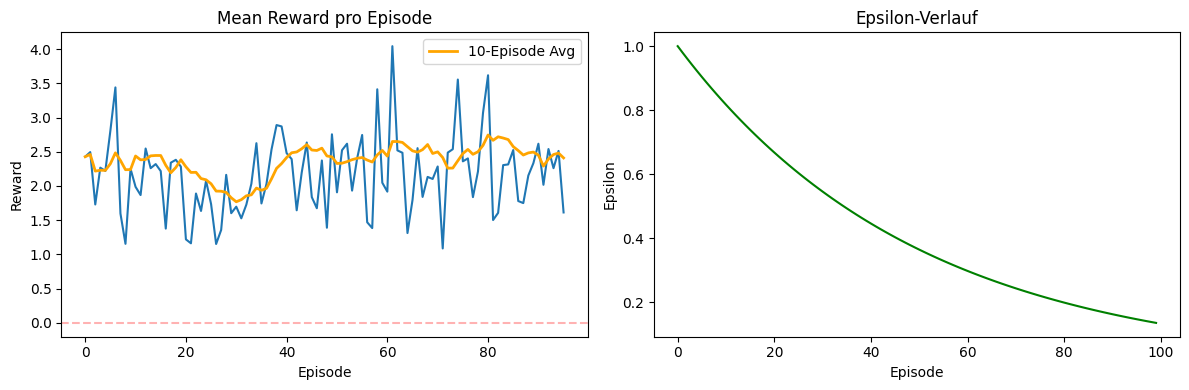

Bester Reward: 4.042 (Episode 61)
Letzter Reward: 1.613
Erster Reward:  2.428


In [ ]:
import matplotlib.pyplot as plt

# Reward-Kurve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mean_reward_per_episode)
plt.title("Mean Reward pro Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

# Gleitender Durchschnitt (zeigt Trend klarer)
window = 10
moving_avg = [sum(mean_reward_per_episode[max(0,i-window):i+1]) / 
              min(i+1, window) for i in range(len(mean_reward_per_episode))]
plt.plot(moving_avg, color='orange', linewidth=2, label=f'{window}-Episode Avg')
plt.legend()

# Epsilon-Verlauf
plt.subplot(1, 2, 2)
epsilon_vec = [1.0 * (EPSILON_DECAY ** i) for i in range(EPISODE_COUNT)]
plt.plot(epsilon_vec, color='green')
plt.title("Epsilon-Verlauf")
plt.xlabel("Episode")
plt.ylabel("Epsilon")

plt.tight_layout()
plt.show()

print(f"Bester Reward: {max(mean_reward_per_episode):.3f} (Episode {mean_reward_per_episode.index(max(mean_reward_per_episode))})")
print(f"Letzter Reward: {mean_reward_per_episode[-1]:.3f}")
print(f"Erster Reward:  {mean_reward_per_episode[0]:.3f}")

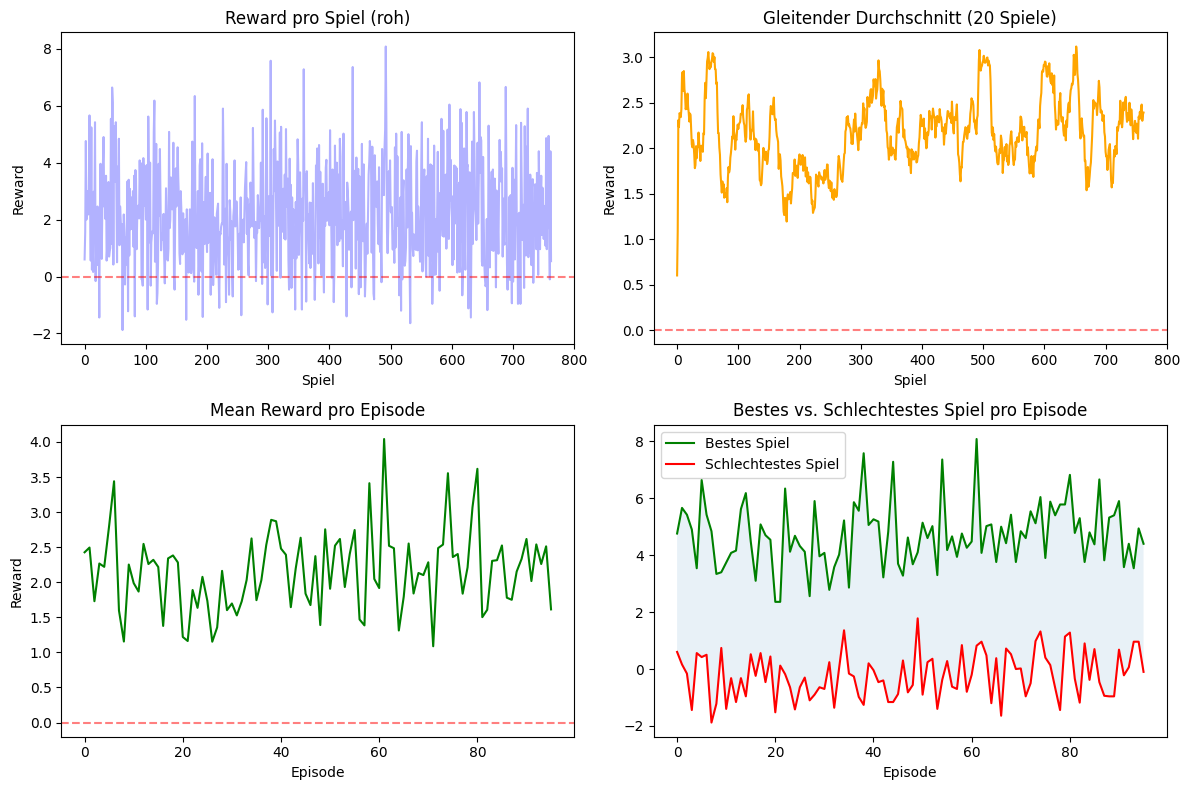

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 1. Reward-Verlauf roh
plt.subplot(2, 2, 1)
plt.plot(reward_vec, alpha=0.3, color='blue')
plt.title("Reward pro Spiel (roh)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 2. Gleitender Durchschnitt über alle Spiele
plt.subplot(2, 2, 2)
window = 20
moving_avg = [np.mean(reward_vec[max(0,i-window):i+1]) 
              for i in range(len(reward_vec))]
plt.plot(moving_avg, color='orange')
plt.title(f"Gleitender Durchschnitt ({window} Spiele)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. Mean Reward pro Episode
plt.subplot(2, 2, 3)
plt.plot(mean_reward_per_episode, color='green')
plt.title("Mean Reward pro Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 4. Beste/Schlechteste Spiele pro Episode
plt.subplot(2, 2, 4)
best_per_ep = [max(reward_vec[i:i+GAMES_PER_EPISODE]) 
               for i in range(0, len(reward_vec), GAMES_PER_EPISODE)]
worst_per_ep = [min(reward_vec[i:i+GAMES_PER_EPISODE]) 
                for i in range(0, len(reward_vec), GAMES_PER_EPISODE)]
plt.plot(best_per_ep, color='green', label='Bestes Spiel')
plt.plot(worst_per_ep, color='red', label='Schlechtestes Spiel')
plt.fill_between(range(len(best_per_ep)), worst_per_ep, best_per_ep, alpha=0.1)
plt.title("Bestes vs. Schlechtestes Spiel pro Episode")
plt.xlabel("Episode")
plt.legend()

plt.tight_layout()
plt.show()

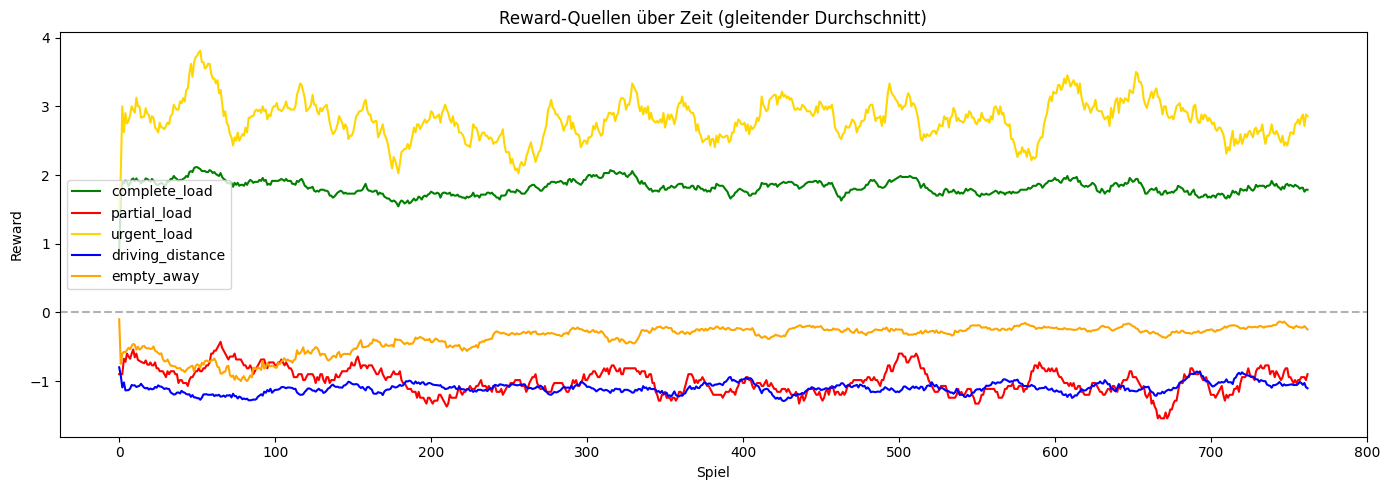


Durchschnitt pro Spiel:
  complete_load       : +1.823
  partial_load        : -1.001
  urgent_load         : +2.817
  driving_distance    : -1.104
  empty_away          : -0.370
  Aktionen/Spiel      : 8.3


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

keys = ['complete_load', 'partial_load', 'urgent_load', 'driving_distance', 'empty_away']
colors = ['green', 'red', 'gold', 'blue', 'orange']

plt.figure(figsize=(14, 5))

# Gleitender Durchschnitt pro Komponente
window = 20
for key, color in zip(keys, colors):
    values = [t[key] for t in tracker_vec]
    moving_avg = [np.mean(values[max(0,i-window):i+1]) 
                  for i in range(len(values))]
    plt.plot(moving_avg, label=key, color=color)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Reward-Quellen über Zeit (gleitender Durchschnitt)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

# Durchschnitt pro Komponente über alle Spiele
print("\nDurchschnitt pro Spiel:")
for key in keys:
    values = [t[key] for t in tracker_vec]
    print(f"  {key:20s}: {np.mean(values):+.3f}")
print(f"  {'Aktionen/Spiel':20s}: {np.mean([t['count_actions'] for t in tracker_vec]):.1f}")

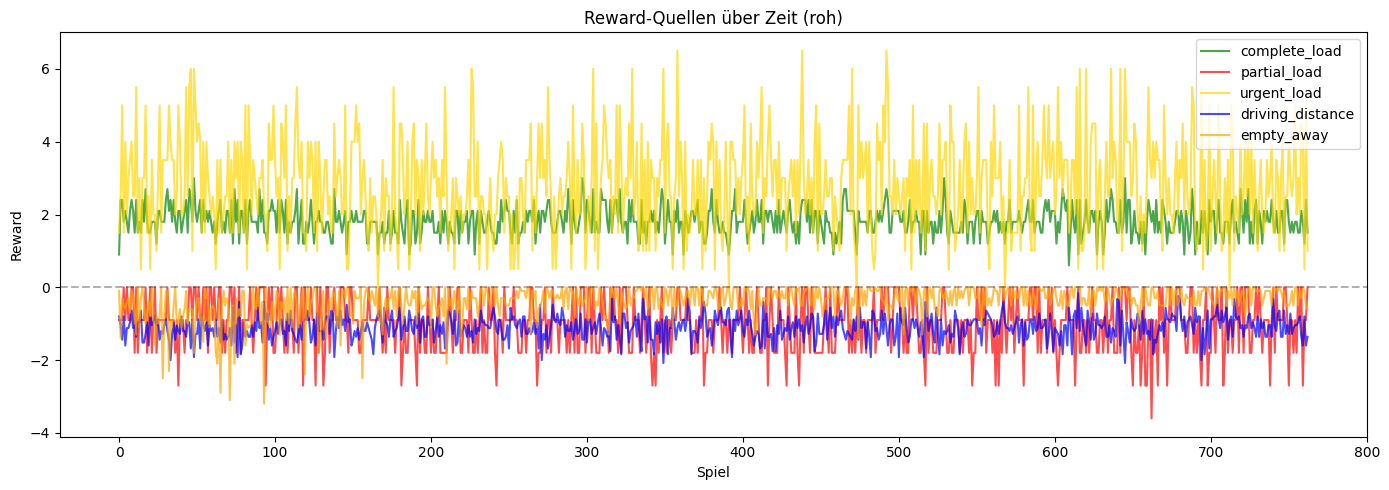

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

keys = ['complete_load', 'partial_load', 'urgent_load', 'driving_distance', 'empty_away']
colors = ['green', 'red', 'gold', 'blue', 'orange']

plt.figure(figsize=(14, 5))

for key, color in zip(keys, colors):
    values = [t[key] for t in tracker_vec]
    plt.plot(values, label=key, color=color, alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Reward-Quellen über Zeit (roh)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

window = 20
moving_avg = [np.mean(points_vec[max(0,i-window):i+1]) 
              for i in range(len(points_vec))]

plt.figure(figsize=(12, 4))
plt.plot(points_vec, alpha=0.3, color='blue', label='Punkte roh')
plt.plot(moving_avg, color='blue', linewidth=2, label=f'{window}-Spiel Durchschnitt')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title("Punkte pro Spiel")
plt.xlabel("Spiel")
plt.ylabel("Punkte")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Durchschnitt: {np.mean(points_vec):.2f}")
print(f"Bestes Spiel: {max(points_vec):.2f}")
print(f"Letztes Spiel: {points_vec[-1]:.2f}")

In [ ]:
#my_RL_agent_storage.memory

In [ ]:
my_RL_agent_storage.model.save('./model_storage.h5')

In [ ]:
#my_RL_agent_storage.model.save('./model_storage.keras')

In [ ]:
import os

base_path = './models/storage_V'
version = 1
while os.path.exists(f'{base_path}{version}.keras'):
    version += 1
my_RL_agent_storage.model.save(f'{base_path}{version}.keras')